In [131]:
import numpy as np
import pandas as pd
import platform
import matplotlib.pyplot as plt

# ── 운영체제별 한글 폰트 설정 ──
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':  # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
else:  # Linux
    plt.rcParams['font.family'] = 'NanumGothic'

# 마이너스 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

In [3]:
# 데이터 불러오기
df = pd.read_csv("C:\hotsix\data\DieCasting_Quality_Raw_Data.csv")

In [44]:
# 불러온 데이터 확인
df.head(5)

,Process,Process.1,Process.2,Process.3,Process.4,Process.5,Process.6,Process.7,Process.8,Process.9,...,Defects.16,Defects.17,Defects.18,Defects.19,Defects.20,Defects.21,Defects.22,Defects.23,Defects.24,Defects.25
0,id,Product_Type,Shot,Velocity_1,Velocity_2,Velocity_3,High_Velocity,Cylinder_Pressure,Rapid_Rise_Time,Biscuit_Thickness,...,Blow_Hole_2,Stain_2,Dent_2,Deformation_2,Contamination_2,Impurity_2,Crack_2,Scratch_2,Buring_Mark_2,Inclusions_2
1,1,1,1,0.144,0.17,0.188,2.134,214,0.008,10,...,0,0,0,0,0,0,0,0,0,0
2,1002,1,2,0.144,0.17,0.182,2.124,217,0.008,11,...,0,0,0,0,0,0,0,0,0,0
3,2003,1,3,0.144,0.17,0.182,2.116,214,0.008,11,...,0,0,0,0,0,0,0,0,0,0
4,3004,1,4,0.144,0.17,0.182,2.137,217,0.008,11,...,0,0,0,0,0,0,0,0,0,0


In [45]:
# 데이터 유형 확인
# 모든 컬럼이 범주형 -> 수치형 변환 필요
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7536 entries, 0 to 7535
Data columns (total 57 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Process     7536 non-null   str  
 1   Process.1   7536 non-null   str  
 2   Process.2   7536 non-null   str  
 3   Process.3   7536 non-null   str  
 4   Process.4   7536 non-null   str  
 5   Process.5   7536 non-null   str  
 6   Process.6   7536 non-null   str  
 7   Process.7   7536 non-null   str  
 8   Process.8   7536 non-null   str  
 9   Process.9   7536 non-null   str  
 10  Process.10  7536 non-null   str  
 11  Process.11  7536 non-null   str  
 12  Process.12  7536 non-null   str  
 13  Process.13  7536 non-null   str  
 14  Process.14  7536 non-null   str  
 15  Process.15  7536 non-null   str  
 16  Process.16  7536 non-null   str  
 17  Sensor      7536 non-null   str  
 18  Sensor.1    7536 non-null   str  
 19  Sensor.2    7536 non-null   str  
 20  Sensor.3    7536 non-null   str  
 21  Se

In [4]:
# 데이터 분리를 위한 공정/센서/불량 데이터 컬럼 이름 목록
process_name = []
sensor_name = []
defects_name = []
col = df.columns.to_list()
for i in col:
    if i.find('Pro') >= 0:
        process_name.append(i)
    elif i.find('Sen') >= 0:
        sensor_name.append(i)
    else:
        defects_name.append(i)

In [5]:
# 공정 데이터 df 저장
df_process = df[process_name]
header = df_process.iloc[0]
df_process = df_process[1:]

# 데이터 형 변환(str -> 수치형), 컬럼 이름 수정(띄어쓰기 오타 수정)
df_process.rename(columns = header, inplace = True)
df_process = df_process.apply(pd.to_numeric, errors = 'coerce')
df_process = df_process.rename(columns = {' Pressure_Rise_Time':'Pressure_Rise_Time'})
df_process.info()

<class 'pandas.DataFrame'>
RangeIndex: 7535 entries, 1 to 7535
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id                  7535 non-null   int64  
 1   Product_Type        7535 non-null   int64  
 2   Shot                7535 non-null   int64  
 3   Velocity_1          7535 non-null   float64
 4   Velocity_2          7535 non-null   float64
 5   Velocity_3          7535 non-null   float64
 6   High_Velocity       7535 non-null   float64
 7   Cylinder_Pressure   7535 non-null   int64  
 8   Rapid_Rise_Time     7535 non-null   float64
 9   Biscuit_Thickness   7535 non-null   int64  
 10  Clamping_Force      7535 non-null   int64  
 11  Cycle_Time          7535 non-null   float64
 12  Pressure_Rise_Time  7535 non-null   float64
 13  Casting_Pressure    7535 non-null   int64  
 14  Spray_Time          7535 non-null   float64
 15  Spray_1_Time        7535 non-null   float64
 16  Spray_2_Time     

In [48]:
df_process.describe()

,id,Product_Type,Shot,Velocity_1,Velocity_2,Velocity_3,High_Velocity,Cylinder_Pressure,Rapid_Rise_Time,Biscuit_Thickness,Clamping_Force,Cycle_Time,Pressure_Rise_Time,Casting_Pressure,Spray_Time,Spray_1_Time,Spray_2_Time
count,7.535000e+03,7535.000000,7535.000000,7535.000000,7535.000000,7535.000000,7535.000000,7535.000000,7535.000000,7535.000000,7535.000000,7535.000000,7535.000000,7535.000000,7535.000000,7535.000000,7535.000000
mean,3.767454e+06,1.441672,453.798938,0.148219,0.168801,0.191193,2.319210,239.655607,0.009596,14.309622,306.433311,27.735979,0.039348,856.944127,9.815979,1.409104,1.396045
std,2.175264e+06,0.496619,319.451698,0.007134,0.004720,0.011563,0.222041,23.305451,0.002148,3.286284,57.274965,8.716156,0.003945,234.815490,1.842438,0.557060,0.716170
min,1.000000e+00,1.000000,0.000000,0.134000,0.158000,0.172000,0.000000,107.000000,0.000000,0.000000,238.000000,20.200000,0.000000,516.000000,7.000000,0.700000,0.700000
25%,1.883893e+06,1.000000,195.000000,0.142000,0.166000,0.181000,2.134000,217.000000,0.008000,11.000000,255.000000,20.900000,0.036000,596.000000,8.000000,0.800000,0.800000
50%,3.767193e+06,1.000000,401.000000,0.144000,0.168000,0.188000,2.161000,239.000000,0.009000,13.000000,258.000000,22.600000,0.041000,1037.000000,9.700000,1.200000,0.800000
75%,5.650924e+06,2.000000,645.000000,0.156000,0.170000,0.202000,2.523000,265.000000,0.012000,17.000000,372.000000,35.900000,0.043000,1053.000000,12.100000,2.000000,2.000000
max,7.534661e+06,2.000000,1296.000000,0.180000,0.212000,0.234000,2.744000,266.000000,0.021000,24.000000,388.000000,218.600000,0.046000,1164.000000,13.100000,2.500000,3.000000


In [6]:
# 센서 데이터 df 저장
df_sensor = df[sensor_name]
header = df_sensor.iloc[0]
df_sensor = df_sensor[1:]

# 데이터 형 변환(str -> 수치형)
df_sensor.rename(columns = header, inplace = True)
df_sensor = df_sensor.apply(pd.to_numeric, errors = 'coerce')
df_sensor.info()

<class 'pandas.DataFrame'>
RangeIndex: 7535 entries, 1 to 7535
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Melting_Furnace_Temp  7535 non-null   float64
 1   Air_Pressure          7535 non-null   float64
 2   Air_Pressure_Min      7535 non-null   int64  
 3   Air_Pressure_Max      7535 non-null   int64  
 4   Coolant_Temp          7535 non-null   float64
 5   Coolant_Temp_Min      7535 non-null   int64  
 6   Coolant_Temp_Max      7535 non-null   int64  
 7   Coolant_Pressure      7535 non-null   float64
 8   Factory_Temp          7445 non-null   float64
 9   Factory_Temp_Min      7445 non-null   float64
 10  Factory_Temp_Max      7445 non-null   float64
 11  Factory_Humidity      7445 non-null   float64
 12  Factory_Humidity_Min  7445 non-null   float64
 13  Factory_Humidity_Max  7445 non-null   float64
dtypes: float64(10), int64(4)
memory usage: 824.3 KB


In [50]:
# Air_Pressure_Min과 Air_Pressure_Max를 비롯한 최대최소값 컬럼은 전부 동일한 값을 가짐
df_sensor.describe()

,Melting_Furnace_Temp,Air_Pressure,Air_Pressure_Min,Air_Pressure_Max,Coolant_Temp,Coolant_Temp_Min,Coolant_Temp_Max,Coolant_Pressure,Factory_Temp,Factory_Temp_Min,Factory_Temp_Max,Factory_Humidity,Factory_Humidity_Min,Factory_Humidity_Max
count,7535.000000,7535.000000,7535.0,7535.0,7535.000000,7535.0,7535.0,7535.000000,7445.000000,7445.0,7445.0,7445.000000,7445.0,7445.0
mean,680.652661,6.109595,3.0,9.0,26.830126,10.0,50.0,2.701155,32.829684,18.0,22.0,61.673002,18.0,22.0
std,25.288666,0.647906,0.0,0.0,0.525149,0.0,0.0,0.052408,1.674896,0.0,0.0,7.031202,0.0,0.0
min,635.300000,4.600000,3.0,9.0,25.900000,10.0,50.0,2.580000,27.400000,18.0,22.0,45.500000,18.0,22.0
25%,656.700000,5.700000,3.0,9.0,26.500000,10.0,50.0,2.640000,31.900000,18.0,22.0,58.000000,18.0,22.0
50%,680.300000,6.200000,3.0,9.0,26.800000,10.0,50.0,2.720000,32.100000,18.0,22.0,63.000000,18.0,22.0
75%,703.100000,6.600000,3.0,9.0,27.200000,10.0,50.0,2.740000,33.800000,18.0,22.0,66.800000,18.0,22.0
max,730.000000,7.100000,3.0,9.0,28.100000,10.0,50.0,2.790000,37.000000,18.0,22.0,72.300000,18.0,22.0


In [ ]:
# info()로 결측치 존재가 예상된 센서 데이터 확인
# 공장 환경 데이터 관련 컬럼 전체가 결측치인 행이 90개인 것으로 추측
df_sensor.isna().sum()

Melting_Furnace_Temp     0
Air_Pressure             0
Air_Pressure_Min         0
Air_Pressure_Max         0
Coolant_Temp             0
Coolant_Temp_Min         0
Coolant_Temp_Max         0
Coolant_Pressure         0
Factory_Temp            90
Factory_Temp_Min        90
Factory_Temp_Max        90
Factory_Humidity        90
Factory_Humidity_Min    90
Factory_Humidity_Max    90
dtype: int64

In [52]:
#  공장 환경 데이터 컬럼에 결측치가 존재하는 행 저장
ft_list = df_sensor[df_sensor["Factory_Temp"].isna()].index.to_list()
ftm_list = df_sensor[df_sensor["Factory_Temp_Min"].isna()].index.to_list()
ftma_list = df_sensor[df_sensor["Factory_Temp_Max"].isna()].index.to_list()
fh_list = df_sensor[df_sensor["Factory_Humidity"].isna()].index.to_list()
fhm_list = df_sensor[df_sensor["Factory_Humidity_Min"].isna()].index.to_list()
fhma_list = df_sensor[df_sensor["Factory_Humidity_Max"].isna()].index.to_list()

# 각 컬럼의 결측치가 있는 행이 전부 동일한지 알아보기 위해 공장 온도와 공장 최대 온도 결측치 행 비교
# 동일 -> 다른 결측치 행도 이름만 바꿔 비교해본 결과 전부 일치하는 것으로 확인
if ftm_list != fhm_list:
    print("다름!")

In [7]:
# 불량 데이터 df 저장
df_defects = df[defects_name]
header = df_defects.iloc[0]
df_defects = df_defects[1:]

# 데이터 형 변환(str -> 수치형)
df_defects.rename(columns = header, inplace = True)
df_defects = df_defects.apply(pd.to_numeric, errors = 'coerce')
df_defects.info()

<class 'pandas.DataFrame'>
RangeIndex: 7535 entries, 1 to 7535
Data columns (total 26 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Short_Shot_1     7535 non-null   int64
 1   Bubble_1         7535 non-null   int64
 2   Exfoliation_1    7535 non-null   int64
 3   Blow_Hole_1      7535 non-null   int64
 4   Stain_1          7535 non-null   int64
 5   Dent_1           7535 non-null   int64
 6   Deformation_1    7535 non-null   int64
 7   Contamination_1  7535 non-null   int64
 8   Impurity_1       7535 non-null   int64
 9   Crack_1          7535 non-null   int64
 10  Scratch_1        7535 non-null   int64
 11  Buring_Mark_1    7535 non-null   int64
 12  Inclusions_1     7535 non-null   int64
 13  Short_Shot_2     7535 non-null   int64
 14  Bubble_2         7535 non-null   int64
 15  Exfoliation_2    7535 non-null   int64
 16  Blow_Hole_2      7535 non-null   int64
 17  Stain_2          7535 non-null   int64
 18  Dent_2           75

In [ ]:
# 불량 유형1 -> Inclusions_1은 불량 데이터 없음
temp1 = df_defects.iloc[:,:13]
temp1.describe()

,Short_Shot_1,Bubble_1,Exfoliation_1,Blow_Hole_1,Stain_1,Dent_1,Deformation_1,Contamination_1,Impurity_1,Crack_1,Scratch_1,Buring_Mark_1,Inclusions_1
count,7535.000000,7535.000000,7535.000000,7535.000000,7535.000000,7535.000000,7535.000000,7535.000000,7535.000000,7535.000000,7535.000000,7535.000000,7535.0
mean,0.067950,0.009555,0.023225,0.032515,0.027737,0.000929,0.014466,0.000531,0.000265,0.000133,0.000265,0.000664,0.0
std,0.259466,0.097290,0.152379,0.195867,0.179668,0.030467,0.120515,0.023036,0.016291,0.011520,0.016291,0.025753,0.0
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
75%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
max,2.000000,1.000000,2.000000,3.000000,2.000000,1.000000,2.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.0


In [ ]:
# 불량 유형2 -> Stain_2, Scratch_2, Buring_Mark2 불량 데이터 없음
temp2 = df_defects.iloc[:,13:]
temp2.describe()

,Short_Shot_2,Bubble_2,Exfoliation_2,Blow_Hole_2,Stain_2,Dent_2,Deformation_2,Contamination_2,Impurity_2,Crack_2,Scratch_2,Buring_Mark_2,Inclusions_2
count,7535.000000,7535.000000,7535.000000,7535.000000,7535.0,7535.000000,7535.000000,7535.000000,7535.000000,7535.000000,7535.0,7535.0,7535.000000
mean,0.024154,0.001194,0.017784,0.021367,0.0,0.000531,0.008626,0.001062,0.000664,0.000265,0.0,0.0,0.000133
std,0.155257,0.041522,0.135152,0.150020,0.0,0.023036,0.093907,0.032569,0.025753,0.016291,0.0,0.0,0.011520
min,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000
75%,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000
max,2.000000,2.000000,2.000000,2.000000,0.0,1.000000,2.000000,1.000000,1.000000,1.000000,0.0,0.0,1.000000


In [ ]:
# 해당하는 불량 유형이 복수인 행 조사
# 여러 불량 유형이 한꺼번에 검출된 데이터 존재
# 하나의 불량이 복수 -> 한 유형에서 심한 불량이 검출된 데이터 존재
df_defects[df_defects.sum(axis = 1) > 2]

,Short_Shot_1,Bubble_1,Exfoliation_1,Blow_Hole_1,Stain_1,Dent_1,Deformation_1,Contamination_1,Impurity_1,Crack_1,...,Blow_Hole_2,Stain_2,Dent_2,Deformation_2,Contamination_2,Impurity_2,Crack_2,Scratch_2,Buring_Mark_2,Inclusions_2
988,1,0,0,0,0,0,1,0,0,0,...,0,0,0,1,0,0,0,0,0,0
4774,0,0,0,1,0,0,0,0,0,0,...,1,0,1,0,0,0,0,0,0,0
4832,1,0,0,2,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4833,1,0,0,2,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4854,0,0,0,2,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
4855,0,0,0,2,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
5116,2,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5117,2,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5170,0,0,0,1,0,0,0,0,0,0,...,2,0,0,0,0,0,0,0,0,0
5171,0,0,0,1,0,0,0,0,0,0,...,2,0,0,0,0,0,0,0,0,0


In [22]:
# 팀장님께서 product1 eda를 그냥 다 해주셔서 짧게나마 해 보는 product2 eda
# product2만 분리
df_2 = df.copy()
header = df_2.iloc[0]
df_2 = df_2[1:]
df_2.rename(columns = header, inplace = True)
df_2 = df_2[df_2["Product_Type"] == "2"]
df_2.head(3)

,id,Product_Type,Shot,Velocity_1,Velocity_2,Velocity_3,High_Velocity,Cylinder_Pressure,Rapid_Rise_Time,Biscuit_Thickness,...,Blow_Hole_2,Stain_2,Dent_2,Deformation_2,Contamination_2,Impurity_2,Crack_2,Scratch_2,Buring_Mark_2,Inclusions_2
4208,4207011,2,11,0.156,0.166,0.192,2.723,265,0.012,20,...,0,0,0,0,0,0,0,0,0,0
4209,4208012,2,12,0.157,0.166,0.204,2.73,264,0.014,19,...,0,0,0,0,0,0,0,0,0,0
4210,4209013,2,13,0.156,0.17,0.204,2.715,265,0.012,18,...,0,0,0,0,0,0,0,0,0,0


In [23]:
# 데이터형 정리(str -> 수치형)
df_2 = df_2.apply(pd.to_numeric, errors = 'coerce')
df_2.info()

<class 'pandas.DataFrame'>
RangeIndex: 3328 entries, 4208 to 7535
Data columns (total 57 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    3328 non-null   int64  
 1   Product_Type          3328 non-null   int64  
 2   Shot                  3328 non-null   int64  
 3   Velocity_1            3328 non-null   float64
 4   Velocity_2            3328 non-null   float64
 5   Velocity_3            3328 non-null   float64
 6   High_Velocity         3328 non-null   float64
 7   Cylinder_Pressure     3328 non-null   int64  
 8   Rapid_Rise_Time       3328 non-null   float64
 9   Biscuit_Thickness     3328 non-null   int64  
 10  Clamping_Force        3328 non-null   int64  
 11  Cycle_Time            3328 non-null   float64
 12   Pressure_Rise_Time   3328 non-null   float64
 13  Casting_Pressure      3328 non-null   int64  
 14  Spray_Time            3328 non-null   float64
 15  Spray_1_Time          3328 no

In [33]:
# product_2의 공정 데이터
df_2_process = df_2.loc[:,:"Spray_2_Time"]
df_2_process = df_2_process.rename(columns = {' Pressure_Rise_Time':'Pressure_Rise_Time'})
df_2_process.info()

<class 'pandas.DataFrame'>
RangeIndex: 3328 entries, 4208 to 7535
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id                  3328 non-null   int64  
 1   Product_Type        3328 non-null   int64  
 2   Shot                3328 non-null   int64  
 3   Velocity_1          3328 non-null   float64
 4   Velocity_2          3328 non-null   float64
 5   Velocity_3          3328 non-null   float64
 6   High_Velocity       3328 non-null   float64
 7   Cylinder_Pressure   3328 non-null   int64  
 8   Rapid_Rise_Time     3328 non-null   float64
 9   Biscuit_Thickness   3328 non-null   int64  
 10  Clamping_Force      3328 non-null   int64  
 11  Cycle_Time          3328 non-null   float64
 12  Pressure_Rise_Time  3328 non-null   float64
 13  Casting_Pressure    3328 non-null   int64  
 14  Spray_Time          3328 non-null   float64
 15  Spray_1_Time        3328 non-null   float64
 16  Spray_2_Time  

In [ ]:
# product_2의 센서 데이터
# 90개의 결측치 행이 product_2에 몰려있음
# 자료에는 중앙값으로 대체하라고 되어 있음
df_2_sensor = df_2.loc[:,"Melting_Furnace_Temp":"Factory_Humidity_Max"]
df_2_sensor.info()

<class 'pandas.DataFrame'>
RangeIndex: 3328 entries, 4208 to 7535
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Melting_Furnace_Temp  3328 non-null   float64
 1   Air_Pressure          3328 non-null   float64
 2   Air_Pressure_Min      3328 non-null   int64  
 3   Air_Pressure_Max      3328 non-null   int64  
 4   Coolant_Temp          3328 non-null   float64
 5   Coolant_Temp_Min      3328 non-null   int64  
 6   Coolant_Temp_Max      3328 non-null   int64  
 7   Coolant_Pressure      3328 non-null   float64
 8   Factory_Temp          3238 non-null   float64
 9   Factory_Temp_Min      3238 non-null   float64
 10  Factory_Temp_Max      3238 non-null   float64
 11  Factory_Humidity      3238 non-null   float64
 12  Factory_Humidity_Min  3238 non-null   float64
 13  Factory_Humidity_Max  3238 non-null   float64
dtypes: float64(10), int64(4)
memory usage: 364.1 KB


In [57]:
df_2_sensor.describe()

,Melting_Furnace_Temp,Air_Pressure,Air_Pressure_Min,Air_Pressure_Max,Coolant_Temp,Coolant_Temp_Min,Coolant_Temp_Max,Coolant_Pressure,Factory_Temp,Factory_Temp_Min,Factory_Temp_Max,Factory_Humidity,Factory_Humidity_Min,Factory_Humidity_Max
count,3328.000000,3328.000000,3328.0,3328.0,3328.000000,3328.0,3328.0,3328.000000,3238.000000,3238.0,3238.0,3238.000000,3238.0,3238.0
mean,655.703996,6.120583,3.0,9.0,26.923347,10.0,50.0,2.689742,32.587616,18.0,22.0,63.159944,18.0,22.0
std,8.494439,0.677288,0.0,0.0,0.551408,0.0,0.0,0.056365,1.540959,0.0,0.0,6.720896,0.0,0.0
min,635.300000,4.600000,3.0,9.0,25.900000,10.0,50.0,2.580000,27.400000,18.0,22.0,45.500000,18.0,22.0
25%,648.700000,5.600000,3.0,9.0,26.500000,10.0,50.0,2.630000,31.600000,18.0,22.0,61.700000,18.0,22.0
50%,655.400000,6.200000,3.0,9.0,26.800000,10.0,50.0,2.700000,32.000000,18.0,22.0,64.300000,18.0,22.0
75%,662.500000,6.800000,3.0,9.0,27.300000,10.0,50.0,2.740000,32.500000,18.0,22.0,69.100000,18.0,22.0
max,678.100000,7.100000,3.0,9.0,28.100000,10.0,50.0,2.790000,37.000000,18.0,22.0,72.300000,18.0,22.0


In [35]:
# product_2의 불량 데이터
df_2_defects = df_2.loc[:,"Short_Shot_1":]
df_2_defects.info()

<class 'pandas.DataFrame'>
RangeIndex: 3328 entries, 4208 to 7535
Data columns (total 26 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Short_Shot_1     3328 non-null   int64
 1   Bubble_1         3328 non-null   int64
 2   Exfoliation_1    3328 non-null   int64
 3   Blow_Hole_1      3328 non-null   int64
 4   Stain_1          3328 non-null   int64
 5   Dent_1           3328 non-null   int64
 6   Deformation_1    3328 non-null   int64
 7   Contamination_1  3328 non-null   int64
 8   Impurity_1       3328 non-null   int64
 9   Crack_1          3328 non-null   int64
 10  Scratch_1        3328 non-null   int64
 11  Buring_Mark_1    3328 non-null   int64
 12  Inclusions_1     3328 non-null   int64
 13  Short_Shot_2     3328 non-null   int64
 14  Bubble_2         3328 non-null   int64
 15  Exfoliation_2    3328 non-null   int64
 16  Blow_Hole_2      3328 non-null   int64
 17  Stain_2          3328 non-null   int64
 18  Dent_2          

c:\hotsix\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


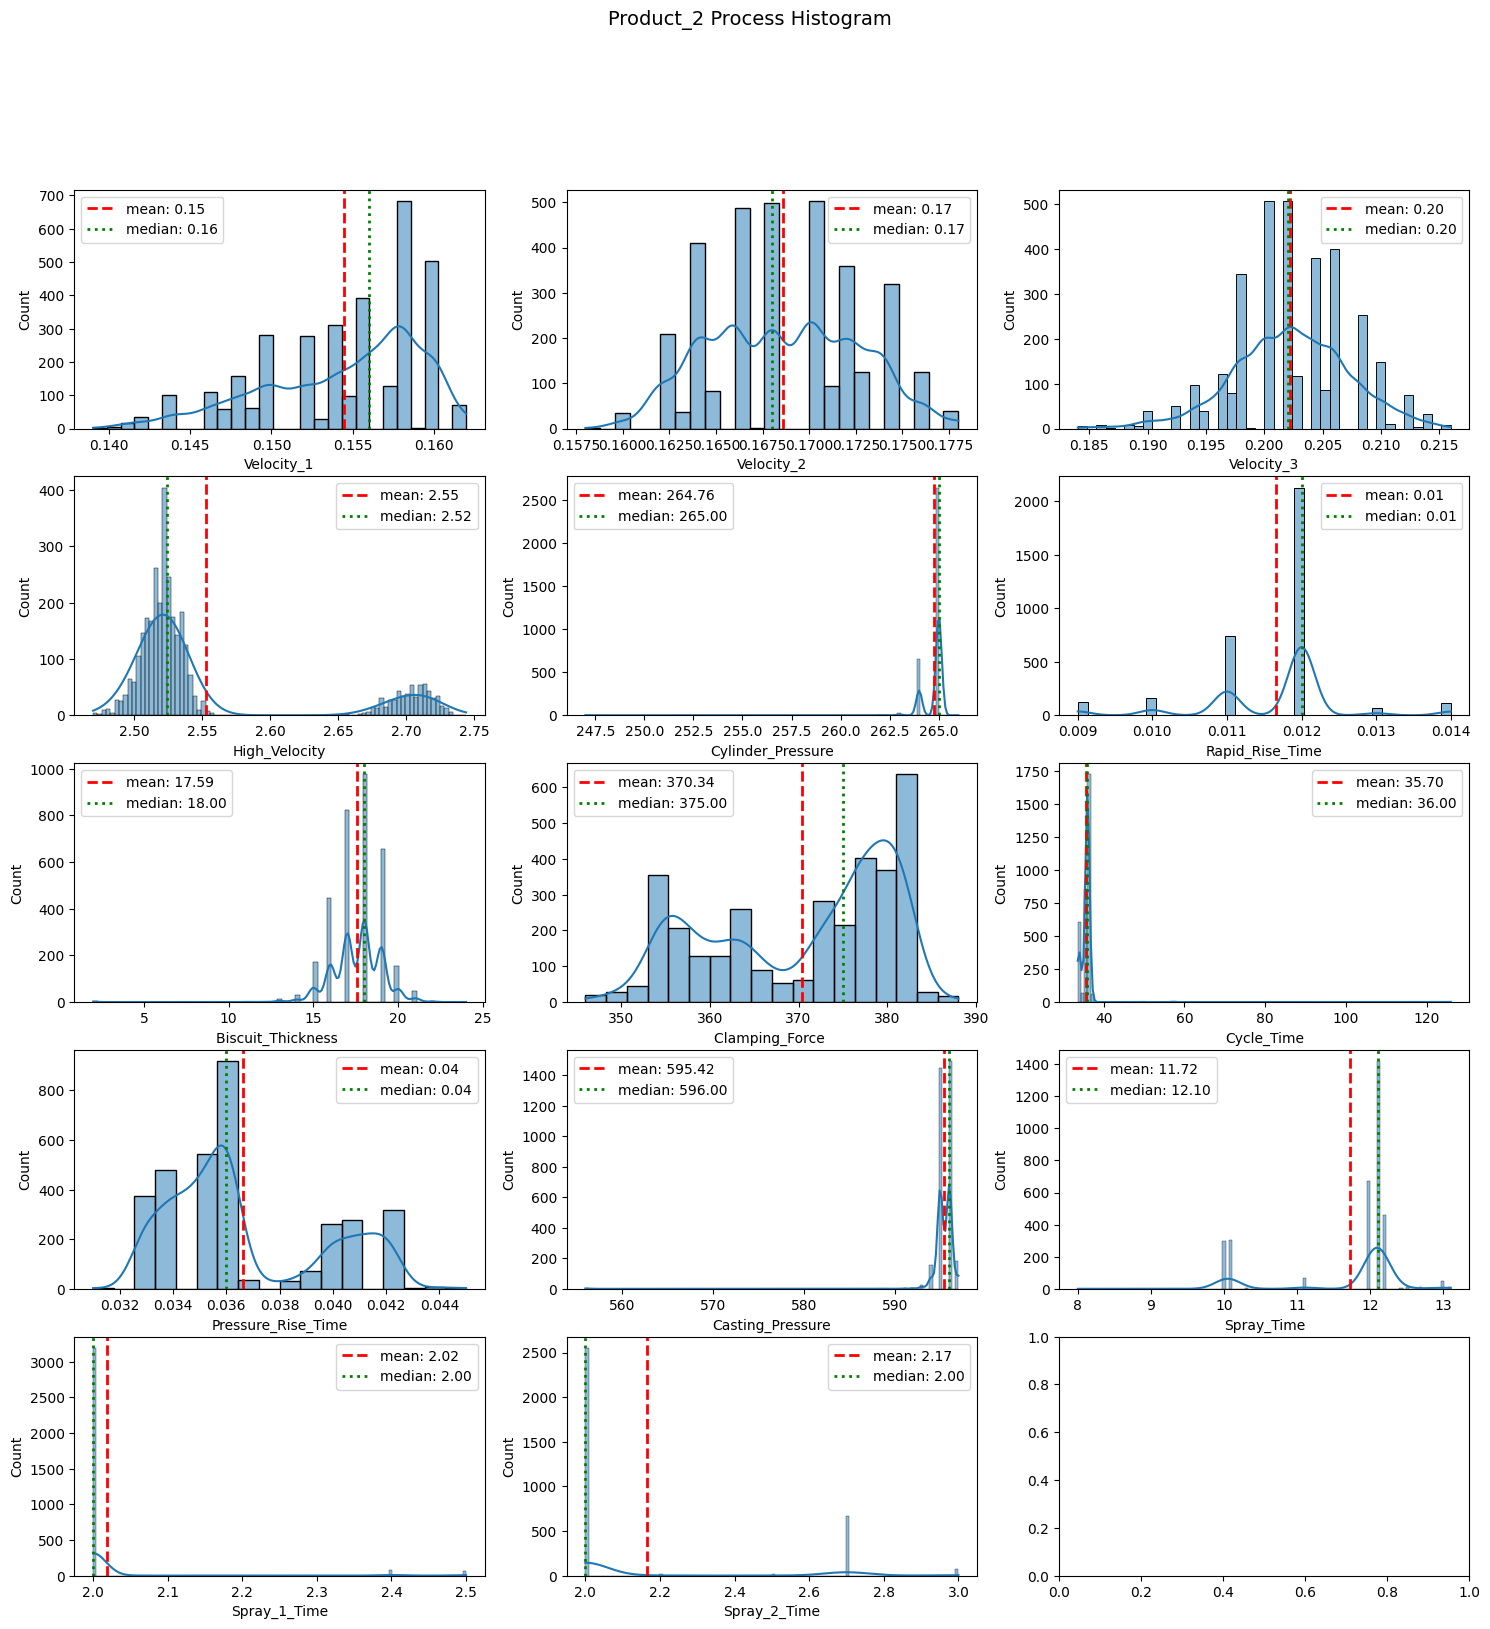

In [ ]:
# 공정 데이터 별 히스토그램
import matplotlib.pyplot as plt
import seaborn as sns
fig, axes = plt.subplots(5, 3, figsize = (18, 18))
fig.suptitle("Product_2 Process Histogram", fontsize = 14)
columns_p2 = df_2_process.columns.to_list()
columns_p2 = columns_p2[3:]
r = 0
c = 0
for i in columns_p2:
    sns.histplot(data = df_2_process, x = i, kde = True, ax = axes[r, c])
    axes[r, c].axvline(df_2_process[i].mean(), color = 'red', linestyle = "--", linewidth = 2, label = f'mean: {df_2_process[i].mean():.2f}')
    axes[r, c].axvline(df_2_process[i].median(), color = 'green', linestyle = ":", linewidth = 2, label = f'median: {df_2_process[i].median():.2f}')
    axes[r, c].legend()
    c += 1
    if c == 3:
        r += 1
        c = 0
        

plt.show()

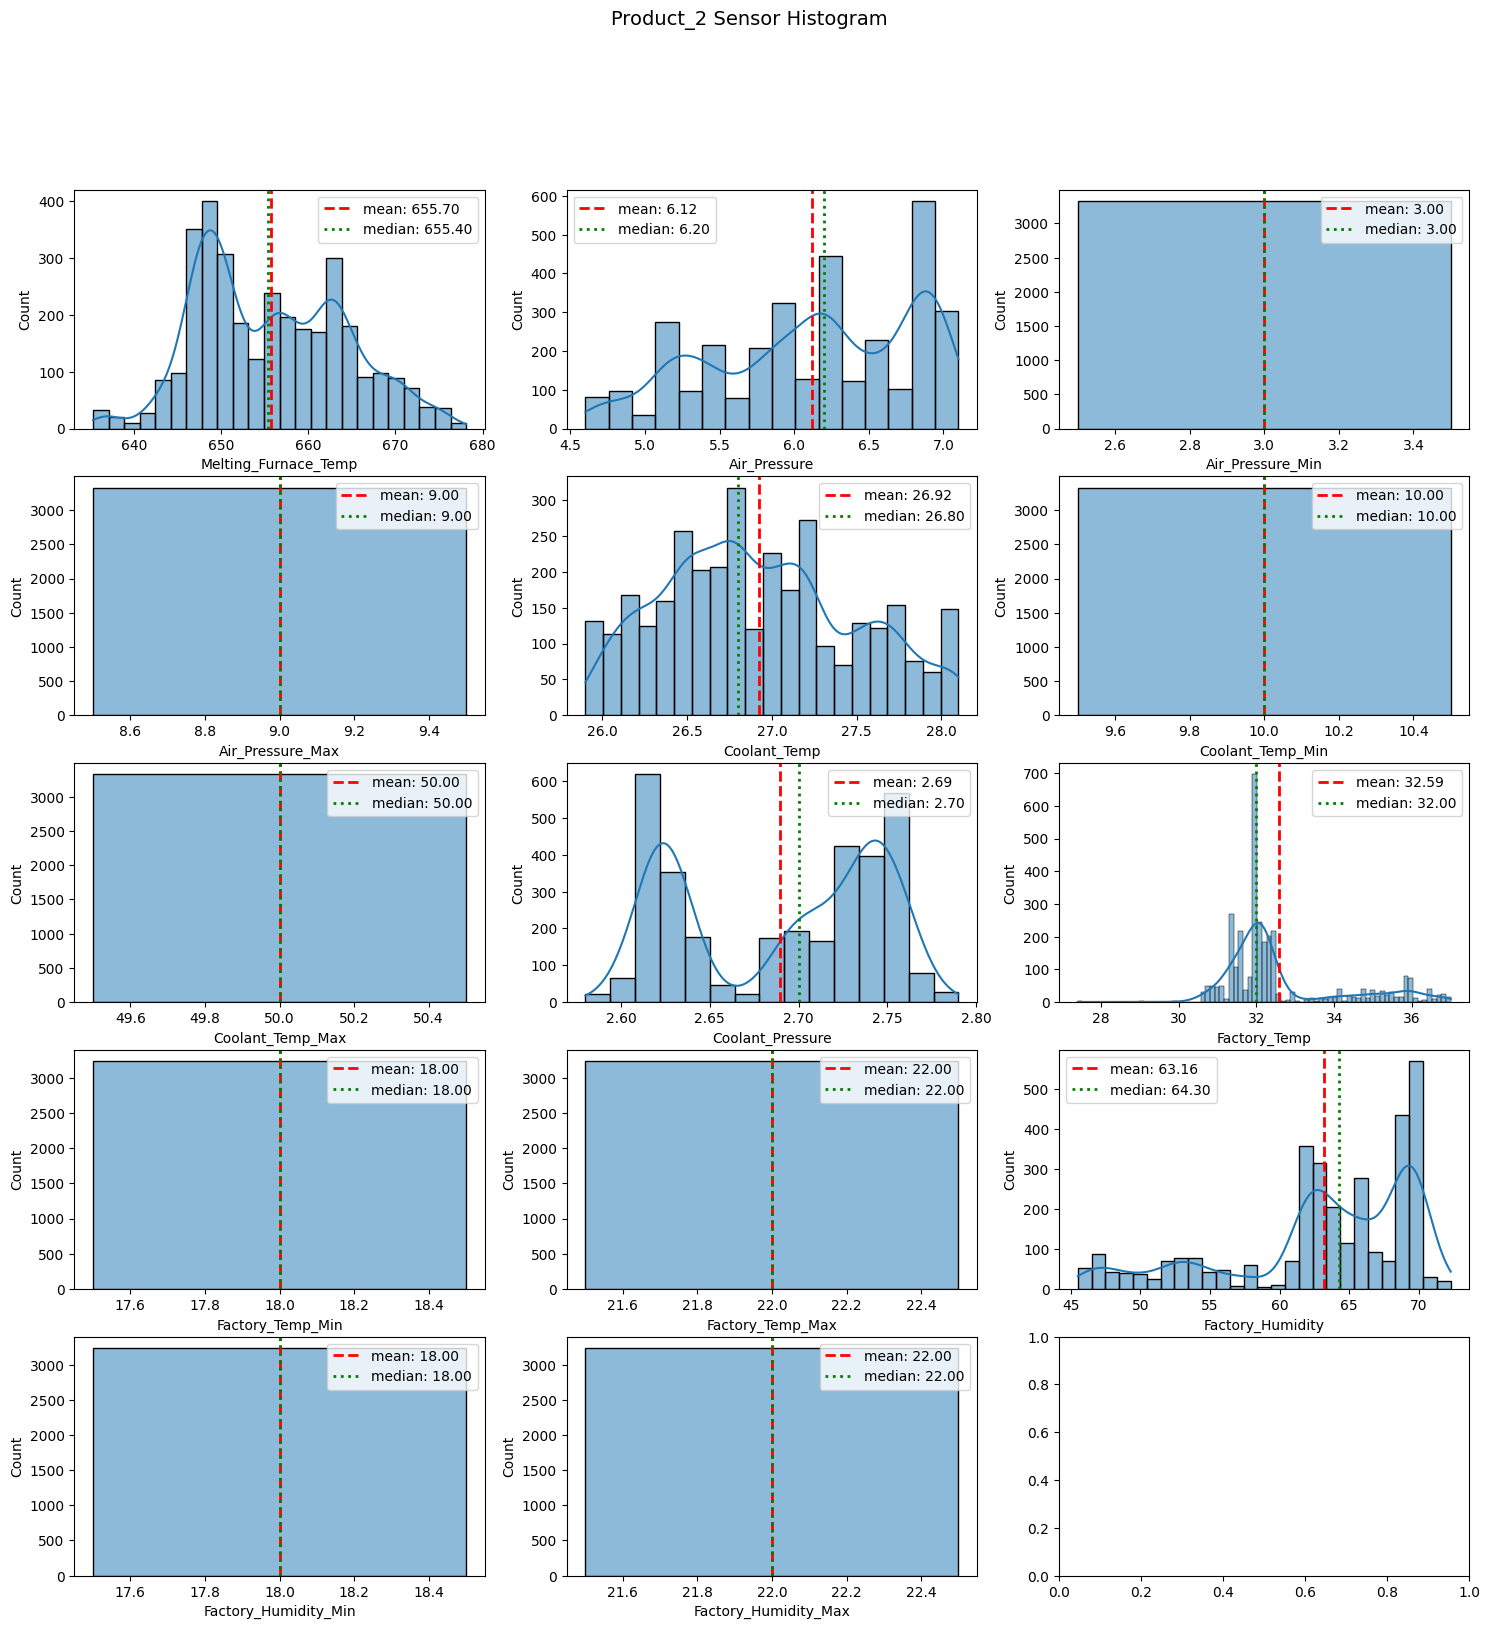

In [ ]:
# 센서 데이터 별 히스토그램
fig, axes = plt.subplots(5, 3, figsize = (18, 18))
fig.suptitle("Product_2 Sensor Histogram", fontsize = 14)
columns_s2 = df_2_sensor.columns.to_list()
r = 0
c = 0
for i in columns_s2:
    sns.histplot(data = df_2_sensor, x = i, kde = True, ax = axes[r, c])
    axes[r, c].axvline(df_2_sensor[i].mean(), color = 'red', linestyle = "--", linewidth = 2, label = f'mean: {df_2_sensor[i].mean():.2f}')
    axes[r, c].axvline(df_2_sensor[i].median(), color = 'green', linestyle = ":", linewidth = 2, label = f'median: {df_2_sensor[i].median():.2f}')
    axes[r, c].legend()
    c += 1
    if c == 3:
        r += 1
        c = 0
        

plt.show()

In [72]:
# product2의 process 데이터 왜도/첨도
df_2_psk = pd.DataFrame({
    "Skewness": df_2_process.skew(),
    "Kurtosis": df_2_process.kurt()
})

# 해석 추가
s_condition = [
    (df_2_psk["Skewness"] < 0),
    (df_2_psk["Skewness"] == 0),
    (df_2_psk["Skewness"] > 0)
]

s_choices = [
    "음의 왜도(대부분 큰 값)",
    "좌우대칭",
    "양의 왜도(대부분 작은 값)"
]

k_condition = [
    (df_2_psk["Kurtosis"] < 0),
    (df_2_psk["Kurtosis"] == 0),
    (df_2_psk["Kurtosis"] > 0)
]

k_choices = [
    "음의 첨도(극단값 거의 없음)",
    "정규분포",
    "양의 첨도(극단값 빈번)"
]

df_2_psk["Skewness Info"] = np.select(s_condition, s_choices, default = "F")
df_2_psk["Kurtosis Info"] = np.select(k_condition, k_choices, default = "F")
df_2_psk

,Skewness,Kurtosis,Skewness Info,Kurtosis Info
id,0.000005,-1.199825,양의 왜도(대부분 작은 값),음의 첨도(극단값 거의 없음)
Product_Type,0.000000,0.000000,좌우대칭,정규분포
Shot,0.067535,-1.134309,양의 왜도(대부분 작은 값),음의 첨도(극단값 거의 없음)
Velocity_1,-0.723734,-0.280219,음의 왜도(대부분 큰 값),음의 첨도(극단값 거의 없음)
Velocity_2,0.066497,-0.811232,양의 왜도(대부분 작은 값),음의 첨도(극단값 거의 없음)
Velocity_3,-0.215835,0.367787,음의 왜도(대부분 큰 값),양의 첨도(극단값 빈번)
High_Velocity,1.579370,0.745153,양의 왜도(대부분 작은 값),양의 첨도(극단값 빈번)
Cylinder_Pressure,-15.937863,364.730170,음의 왜도(대부분 큰 값),양의 첨도(극단값 빈번)
Rapid_Rise_Time,-0.645471,2.402679,음의 왜도(대부분 큰 값),양의 첨도(극단값 빈번)
Biscuit_Thickness,-1.538814,14.104029,음의 왜도(대부분 큰 값),양의 첨도(극단값 빈번)


In [73]:
# product2의 process 데이터 왜도/첨도
df_2_ssk = pd.DataFrame({
    "Skewness": df_2_sensor.skew(),
    "Kurtosis": df_2_sensor.kurt()
})

# 해석 추가
s_condition = [
    (df_2_ssk["Skewness"] < 0),
    (df_2_ssk["Skewness"] == 0),
    (df_2_ssk["Skewness"] > 0)
]

s_choices = [
    "음의 왜도(대부분 큰 값)",
    "좌우대칭",
    "양의 왜도(대부분 작은 값)"
]

k_condition = [
    (df_2_ssk["Kurtosis"] < 0),
    (df_2_ssk["Kurtosis"] == 0),
    (df_2_ssk["Kurtosis"] > 0)
]

k_choices = [
    "음의 첨도(극단값 거의 없음)",
    "정규분포",
    "양의 첨도(극단값 빈번)"
]

df_2_ssk["Skewness Info"] = np.select(s_condition, s_choices, default = "F")
df_2_ssk["Kurtosis Info"] = np.select(k_condition, k_choices, default = "F")
df_2_ssk

,Skewness,Kurtosis,Skewness Info,Kurtosis Info
Melting_Furnace_Temp,0.273951,-0.647366,양의 왜도(대부분 작은 값),음의 첨도(극단값 거의 없음)
Air_Pressure,-0.378966,-0.930384,음의 왜도(대부분 큰 값),음의 첨도(극단값 거의 없음)
Air_Pressure_Min,0.000000,0.000000,좌우대칭,정규분포
Air_Pressure_Max,0.000000,0.000000,좌우대칭,정규분포
Coolant_Temp,0.282971,-0.738899,양의 왜도(대부분 작은 값),음의 첨도(극단값 거의 없음)
Coolant_Temp_Min,0.000000,0.000000,좌우대칭,정규분포
Coolant_Temp_Max,0.000000,0.000000,좌우대칭,정규분포
Coolant_Pressure,-0.210328,-1.543214,음의 왜도(대부분 큰 값),음의 첨도(극단값 거의 없음)
Factory_Temp,1.361004,0.881630,양의 왜도(대부분 작은 값),양의 첨도(극단값 빈번)
Factory_Temp_Min,0.000000,0.000000,좌우대칭,정규분포


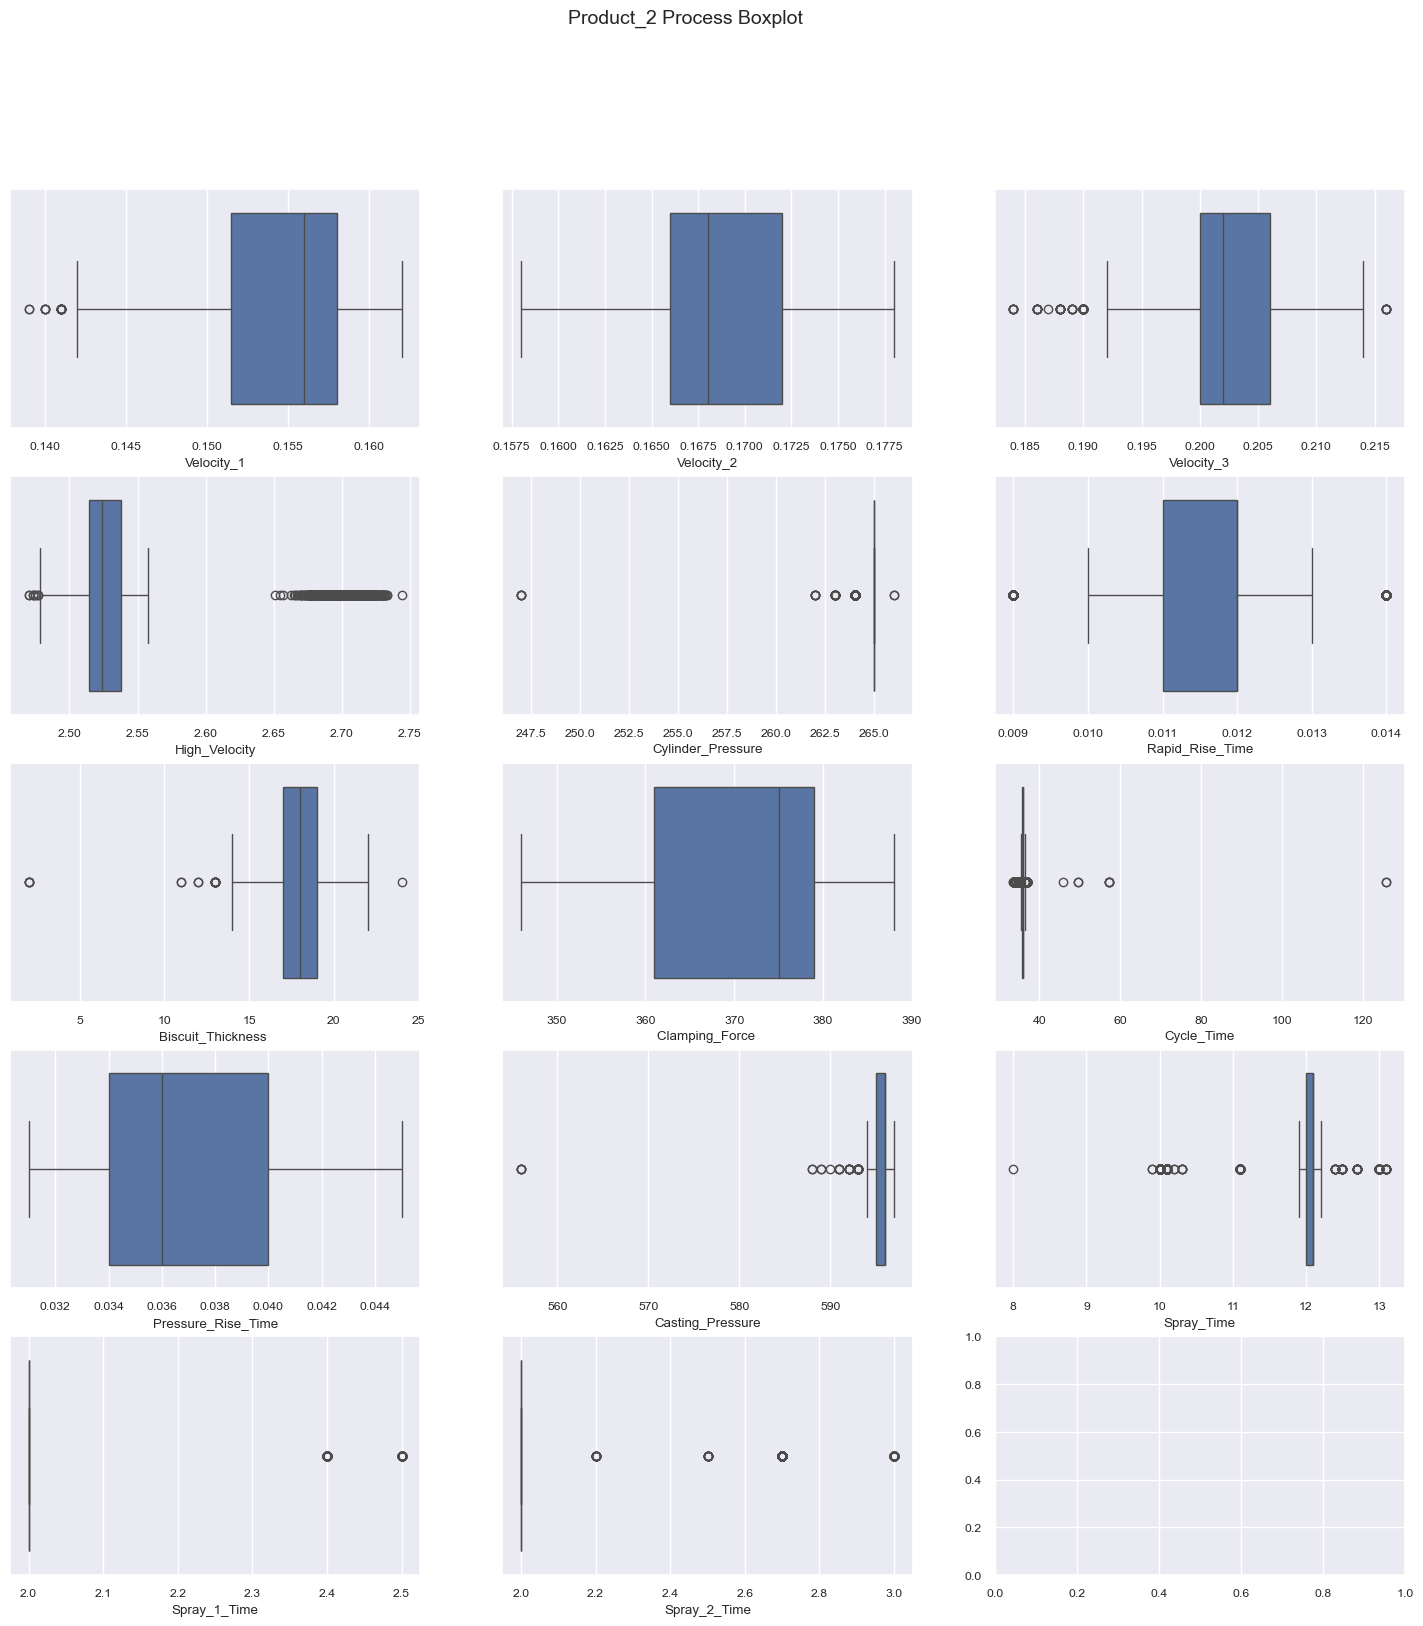

In [88]:
# process별 box plot
fig, axes = plt.subplots(5, 3, figsize = (18, 18))
fig.suptitle("Product_2 Process Boxplot", fontsize = 14)
sns.set_theme(font_scale = 0.5)
columns_p2 = df_2_process.columns.to_list()
columns_p2 = columns_p2[3:]
r = 0
c = 0
for i in columns_p2:
    sns.boxplot(data = df_2_process, x = i, ax = axes[r, c])
    c += 1
    if c == 3:
        r += 1
        c = 0
        

plt.show()

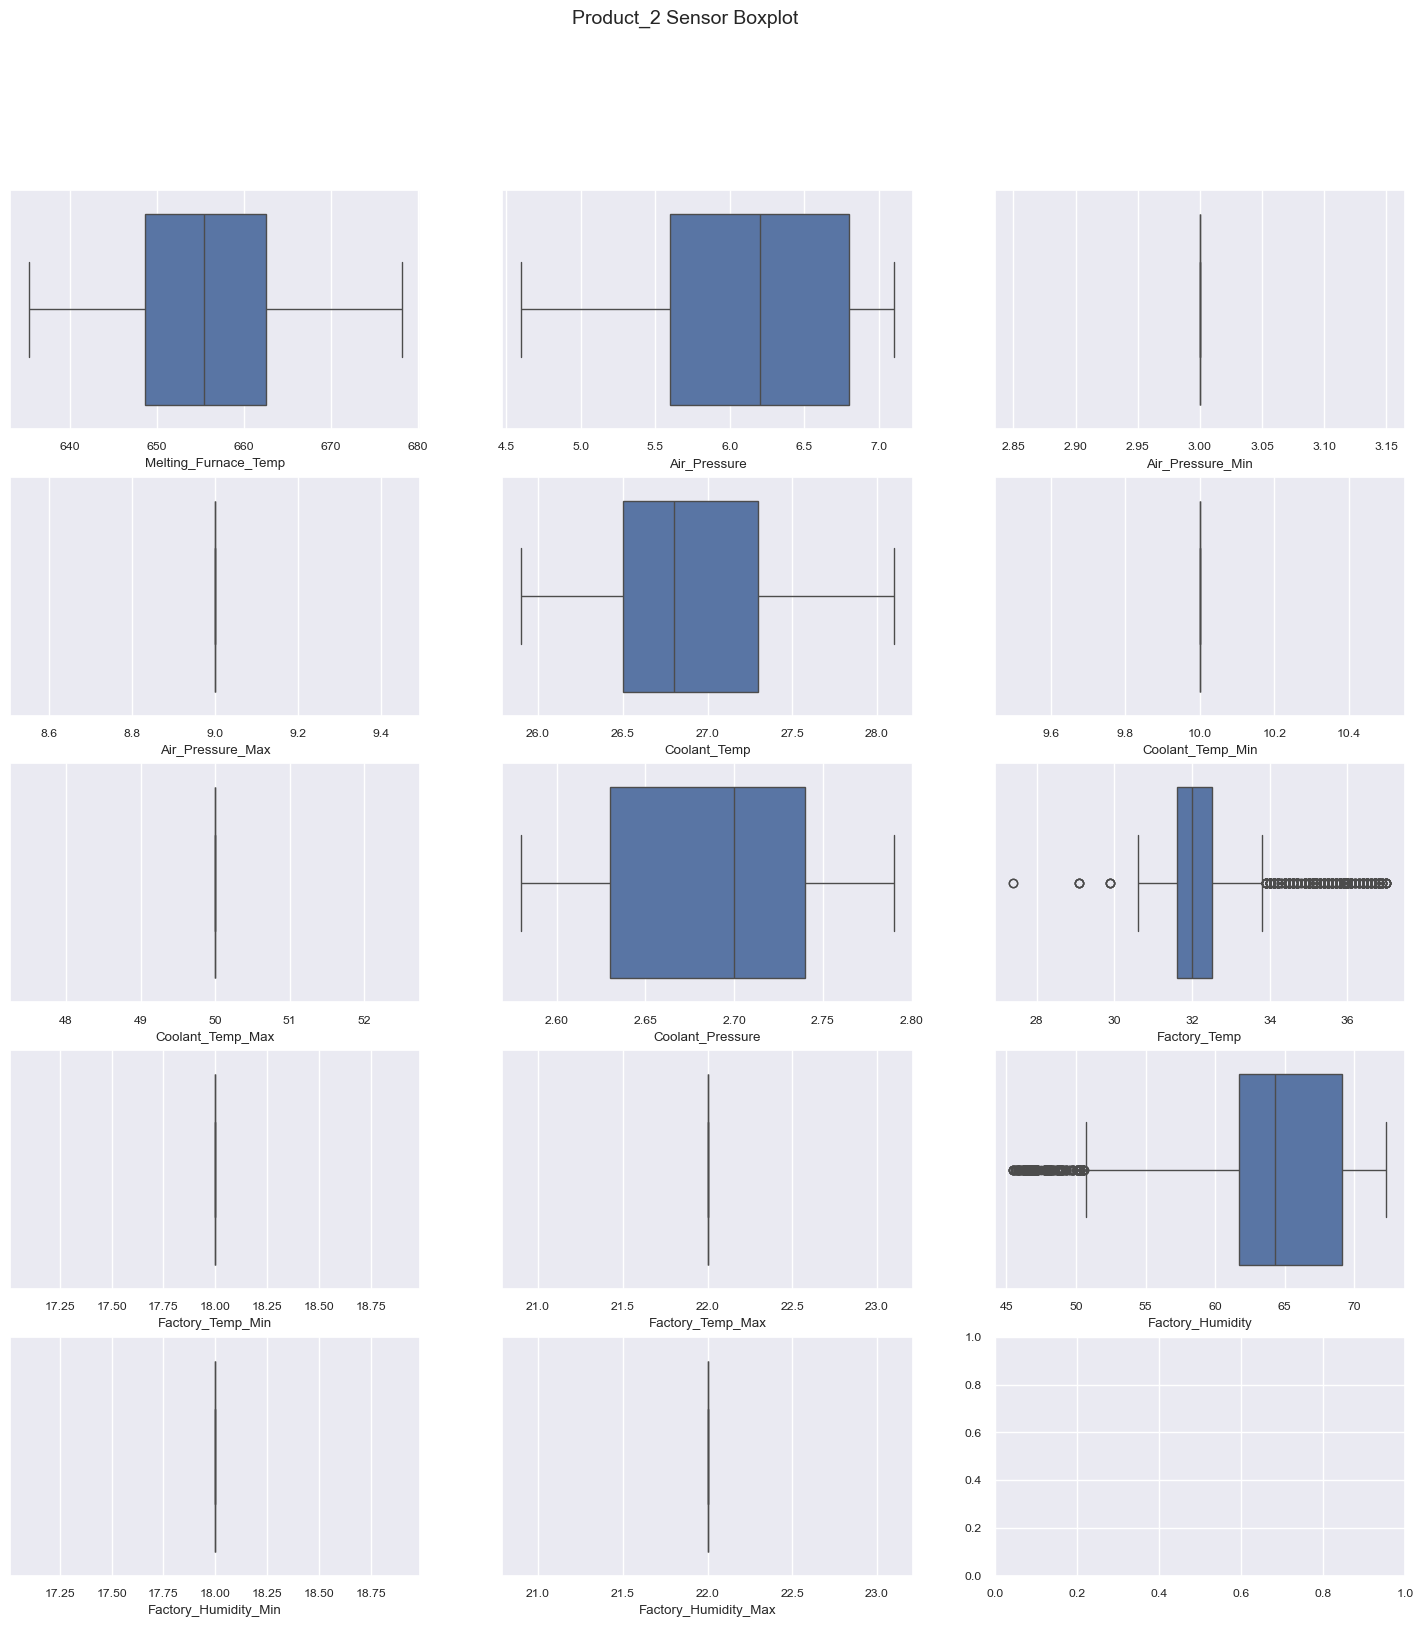

In [90]:
# sensor별 box plot
fig, axes = plt.subplots(5, 3, figsize = (18, 18))
fig.suptitle("Product_2 Sensor Boxplot", fontsize = 14)
sns.set_theme(font_scale = 0.9)
columns_s2 = df_2_sensor.columns.to_list()
r = 0
c = 0
for i in columns_s2:
    sns.boxplot(data = df_2_sensor, x = i, ax = axes[r, c])
    c += 1
    if c == 3:
        r += 1
        c = 0
        

plt.show()

In [125]:
# 불량 유형별 분포를 보기 위해 불량 발생 여부(0/1)로 매핑 -> 값을 합한 series 생성
df_2_defects_r = df_2_defects.copy()
col_r = df_2_defects_r.columns.to_list()
for i in col_r:
    df_2_defects_r[i] = df_2_defects_r[i].map(lambda x: 1 if x > 0 else 0)

df_2_defects_r = df_2_defects_r.sum()
df_2_defects_r = df_2_defects_r.sort_values(ascending = False)
df_2_defects_r
    

Short_Shot_1       351
Blow_Hole_1        221
Stain_1            186
Blow_Hole_2        155
Short_Shot_2        94
Contamination_2      8
Buring_Mark_1        5
Impurity_2           5
Contamination_1      4
Dent_1               4
Dent_2               4
Impurity_1           2
Crack_2              2
Scratch_1            2
Inclusions_2         1
Bubble_1             1
Crack_1              1
Exfoliation_1        0
Deformation_1        0
Exfoliation_2        0
Bubble_2             0
Inclusions_1         0
Stain_2              0
Deformation_2        0
Scratch_2            0
Buring_Mark_2        0
dtype: int64

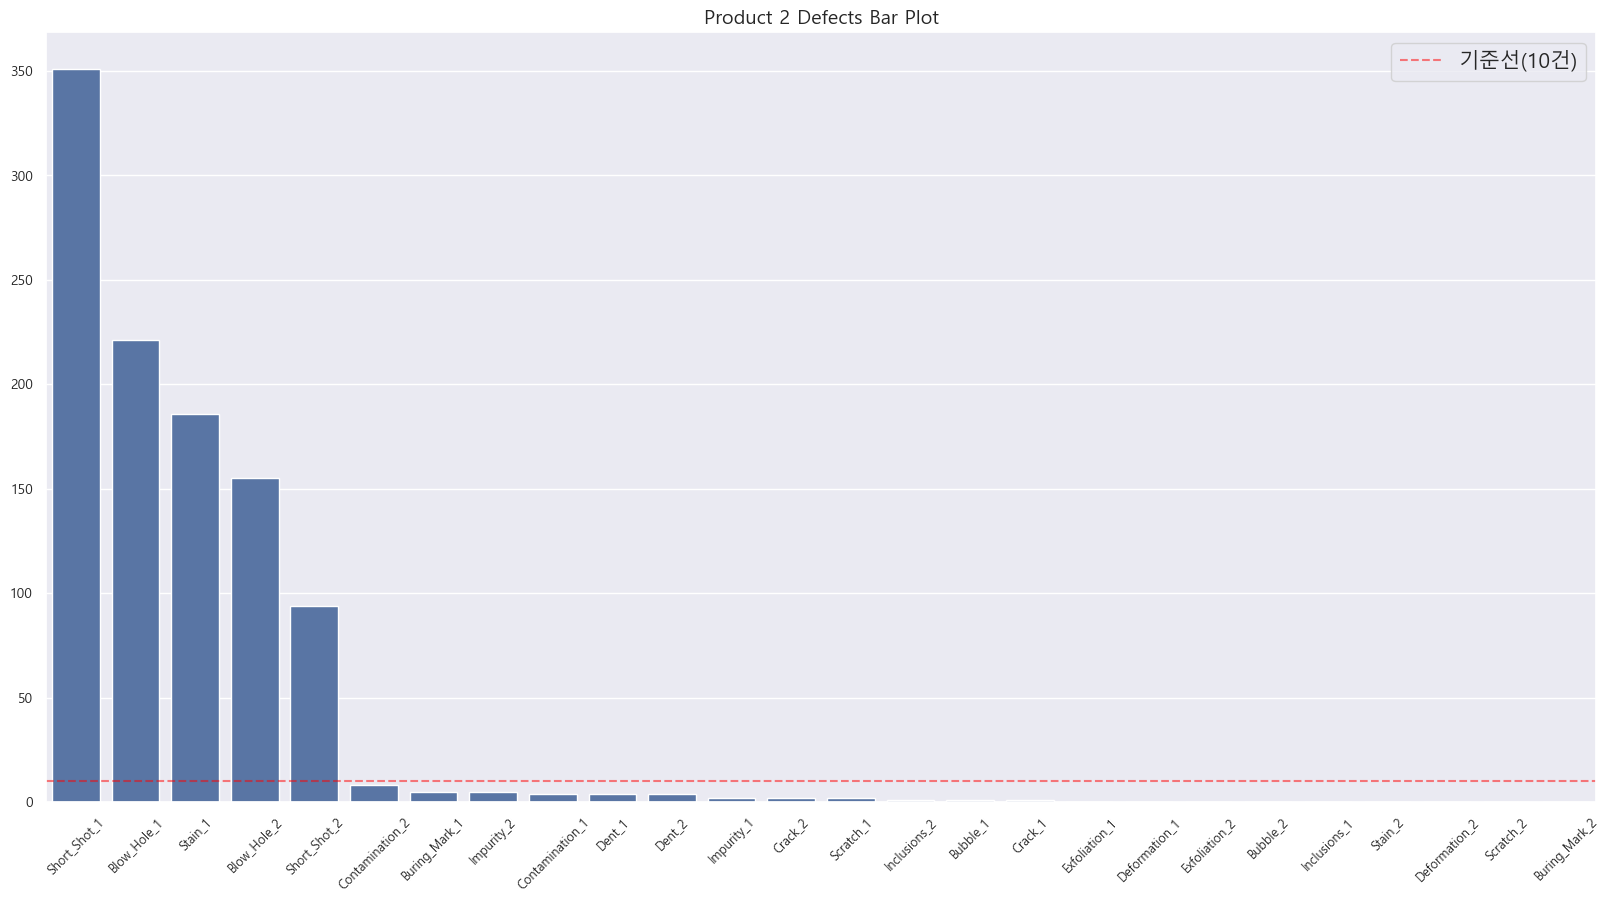

In [133]:
plt.figure(figsize = (20, 10))
sns.barplot(data = df_2_defects_r)
plt.title("Product 2 Defects Bar Plot", fontsize = 14)
plt.xticks(rotation = 45, fontsize = 9)
plt.axhline(y = 10, color = 'red', linestyle = "--", alpha = 0.5, label = "기준선(10건)")
plt.legend(fontsize = 15)
plt.show()

In [ ]:
# product2 데이터 중 전체 중복
print("Product_2 전체 중복 행: ", df_2.duplicated().sum())

df_2_drop = df_2.iloc[:, 2:]

# id를 제외한 실질적 중복
print("Product_2 id 제외 중복 행: ", df_2_drop.duplicated().sum())

Product_2 전체 중복 행:  0
Product_2 id 제외 중복 행:  1364


In [140]:
# 중복 행 상세 확인
duplicated_rows = df_2_drop[df_2_drop.duplicated(keep = False)]
print(f"중복 관련 행 수: {len(duplicated_rows)}")
duplicated_rows.sort_values(by = 'Shot').head(20)

중복 관련 행 수: 2728


,Shot,Velocity_1,Velocity_2,Velocity_3,High_Velocity,Cylinder_Pressure,Rapid_Rise_Time,Biscuit_Thickness,Clamping_Force,Cycle_Time,...,Blow_Hole_2,Stain_2,Dent_2,Deformation_2,Contamination_2,Impurity_2,Crack_2,Scratch_2,Buring_Mark_2,Inclusions_2
4808,0,0.156,0.170,0.208,2.533,265,0.012,16,355,33.9,...,0,0,0,0,0,0,0,0,0,0
4809,0,0.156,0.170,0.208,2.533,265,0.012,16,355,33.9,...,0,0,0,0,0,0,0,0,0,0
4810,1,0.156,0.170,0.208,2.533,265,0.012,16,355,33.9,...,0,0,0,0,0,0,0,0,0,0
4811,1,0.156,0.170,0.208,2.533,265,0.012,16,355,33.9,...,0,0,0,0,0,0,0,0,0,0
4813,2,0.149,0.174,0.204,2.506,264,0.012,16,357,33.9,...,0,0,0,0,0,0,0,0,0,0
4812,2,0.149,0.174,0.204,2.506,264,0.012,16,357,33.9,...,0,0,0,0,0,0,0,0,0,0
4814,3,0.144,0.164,0.203,2.529,264,0.012,13,361,33.9,...,0,0,0,0,0,0,0,0,0,0
4815,3,0.144,0.164,0.203,2.529,264,0.012,13,361,33.9,...,0,0,0,0,0,0,0,0,0,0
4817,4,0.158,0.160,0.204,2.506,265,0.012,15,361,33.9,...,0,0,0,0,0,0,0,0,0,0
4816,4,0.158,0.160,0.204,2.506,265,0.012,15,361,33.9,...,0,0,0,0,0,0,0,0,0,0


In [141]:
# 결측값 확인
missing_counts = df_2.isna().sum()
missing_cols = missing_counts[missing_counts > 0]

missing_df = pd.DataFrame({
    "missing_count" : missing_cols,
    "missing_ratio(%)" : df_2[missing_cols.index].isna().mean() * 100
}).sort_values("missing_count", ascending = False)

print("결측치 보유 컬럼:")
display(missing_df)

결측치 보유 컬럼:


,missing_count,missing_ratio(%)
Factory_Temp,90,2.704327
Factory_Temp_Min,90,2.704327
Factory_Temp_Max,90,2.704327
Factory_Humidity,90,2.704327
Factory_Humidity_Min,90,2.704327
Factory_Humidity_Max,90,2.704327


In [ ]:
df_2.loc[missing_counts.index.to_list()]

In [149]:
df["Process.2"].value_counts()

Process.2
44     12
45     12
46     12
47     12
11     10
       ..
973     1
974     1
975     1
976     1
977     1
Name: count, Length: 1272, dtype: int64